**Downloading the zip files :**

In [ ]:
!pip install awscli

In [ ]:
!aws s3 sync --no-sign-request s3://physionet-open/challenge-2019/1.0.0/ /content/sepsis_data/

### **DATA LOADING :**

In [ ]:
from glob import glob

files = glob("/content/sepsis_data/**/*.psv", recursive=True)
print("Total files:", len(files))

Total files: 40336


**Load and combine all patient files :**

In [ ]:
import pandas as pd
import os
from glob import glob

# Get all patient files
all_files = glob("/content/sepsis_data/**/*.psv", recursive=True)

print("Total patient files:", len(all_files))

dfs = []

for file in all_files:
    df = pd.read_csv(file, sep="|")
    df["patient_id"] = os.path.basename(file)
    dfs.append(df)

# Combine all
full_df = pd.concat(dfs, ignore_index=True)

print("Final dataset shape:", full_df.shape)
full_df.head()

Total patient files: 40336
Final dataset shape: (1552210, 42)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,45.0,0,0.0,1.0,-0.02,1,0,p118461.psv
1,100.0,100.0,37.70,122.0,84.0,68.0,11.0,18.0,NaN,NaN,...,NaN,NaN,45.0,0,0.0,1.0,-0.02,2,0,p118461.psv
2,84.0,100.0,37.05,108.0,80.0,68.0,10.0,15.0,NaN,NaN,...,NaN,NaN,45.0,0,0.0,1.0,-0.02,3,0,p118461.psv
3,82.0,100.0,36.50,110.0,81.0,67.0,12.0,14.0,NaN,NaN,...,NaN,NaN,45.0,0,0.0,1.0,-0.02,4,0,p118461.psv
4,73.0,99.0,36.95,131.0,92.0,73.0,12.0,15.5,NaN,NaN,...,NaN,NaN,45.0,0,0.0,1.0,-0.02,5,0,p118461.psv


**Checking dataset :**

In [ ]:
print("Shape:",full_df.shape)
print("Column names:",full_df.columns)
print("Info:",full_df.info())
print(full_df["SepsisLabel"].value_counts())

Shape: (1552210, 42)
Column names: Index(['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
       'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
       'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
       'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
       'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'patient_id'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 42 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   HR                1398811 non-null  float64
 1   O2Sat             1349474 non-null  float64
 2   Temp              525226 non-null   float64
 3   SBP               1325945 non-null  float64
 4   MAP               1358940 non-null  float64

### **DATA PREPROCESSING :**

**Check missing values :**

In [ ]:
missing_values = full_df.isnull().sum().sort_values(ascending=False)
print(missing_values)

Bilirubin_direct    1549220
Fibrinogen          1541968
TroponinI           1537429
Bilirubin_total     1529069
Alkalinephos        1527269
AST                 1527027
Lactate             1510764
PTT                 1506511
SaO2                1498649
EtCO2               1494574
Phosphate           1489909
HCO3                1487182
Chloride            1481744
BaseExcess          1468065
PaCO2               1465909
Calcium             1460879
Platelets           1460001
Creatinine          1457594
Magnesium           1454259
WBC                 1452763
BUN                 1445642
pH                  1444637
Hgb                 1437619
FiO2                1422845
Hct                 1414777
Potassium           1407685
Glucose             1286694
Temp                1026984
Unit2                611960
Unit1                611960
DBP                  486554
Resp                 238335
SBP                  226265
O2Sat                202736
MAP                  193270
HR                  

**Convert counts → percentage :**

In [ ]:
missing_percent = (full_df.isnull().sum() / len(full_df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent)

Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
BUN                 93.134434
pH                  93.069688
Hgb                 92.617558
FiO2                91.665754
Hct                 91.145979
Potassium           90.689082
Glucose             82.894325
Temp                66.162697
Unit2               39.425078
Unit1               39.425078
DBP                 31.345887
Resp                15.354559
SBP                 14.576958
O2Sat     

In [ ]:
threshold = 95

cols_to_drop = missing_percent[missing_percent > threshold].index
print("Dropping columns:", cols_to_drop)

full_df = full_df.drop(columns=cols_to_drop)

print("Remaining columns:", full_df.shape[1])

Dropping columns: Index(['Bilirubin_direct', 'Fibrinogen', 'TroponinI', 'Bilirubin_total',
       'Alkalinephos', 'AST', 'Lactate', 'PTT', 'SaO2', 'EtCO2', 'Phosphate',
       'HCO3', 'Chloride'],
      dtype='object')
Remaining columns: 29


**Sort data :**

In [ ]:
full_df = full_df.sort_values(by=["patient_id", "ICULOS"])
print(full_df.head())

            HR  O2Sat  Temp    SBP    MAP  DBP  Resp  BaseExcess  FiO2    pH  \
1165052    NaN    NaN   NaN    NaN    NaN  NaN   NaN         NaN   NaN   NaN   
1165053   97.0   95.0   NaN   98.0  75.33  NaN  19.0         NaN   NaN   NaN   
1165054   89.0   99.0   NaN  122.0  86.00  NaN  22.0         NaN   NaN   NaN   
1165055   90.0   95.0   NaN    NaN    NaN  NaN  30.0        24.0   NaN  7.36   
1165056  103.0   88.5   NaN  122.0  91.33  NaN  24.5         NaN  0.28   NaN   

         ...  WBC  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  \
1165052  ...  NaN        NaN  83.14       0    NaN    NaN        -0.03   
1165053  ...  NaN        NaN  83.14       0    NaN    NaN        -0.03   
1165054  ...  NaN        NaN  83.14       0    NaN    NaN        -0.03   
1165055  ...  NaN        NaN  83.14       0    NaN    NaN        -0.03   
1165056  ...  NaN        NaN  83.14       0    NaN    NaN        -0.03   

         ICULOS  SepsisLabel   patient_id  
1165052       1            0  

**Forward fill (within each patient) :**

In [ ]:
full_df = full_df.groupby("patient_id").apply(lambda x: x.ffill()).reset_index(drop=True)
print(full_df.head())

/tmp/ipykernel_48695/2478659100.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  full_df = full_df.groupby("patient_id").apply(lambda x: x.ffill()).reset_index(drop=True)


      HR  O2Sat  Temp    SBP    MAP  DBP  Resp  BaseExcess  FiO2    pH  ...  \
0    NaN    NaN   NaN    NaN    NaN  NaN   NaN         NaN   NaN   NaN  ...   
1   97.0   95.0   NaN   98.0  75.33  NaN  19.0         NaN   NaN   NaN  ...   
2   89.0   99.0   NaN  122.0  86.00  NaN  22.0         NaN   NaN   NaN  ...   
3   90.0   95.0   NaN  122.0  86.00  NaN  30.0        24.0   NaN  7.36  ...   
4  103.0   88.5   NaN  122.0  91.33  NaN  24.5        24.0  0.28  7.36  ...   

   WBC  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  \
0  NaN        NaN  83.14       0    NaN    NaN        -0.03       1   
1  NaN        NaN  83.14       0    NaN    NaN        -0.03       2   
2  NaN        NaN  83.14       0    NaN    NaN        -0.03       3   
3  NaN        NaN  83.14       0    NaN    NaN        -0.03       4   
4  NaN        NaN  83.14       0    NaN    NaN        -0.03       5   

   SepsisLabel   patient_id  
0            0  p000001.psv  
1            0  p000001.psv  
2       

**Backward fill (within each patient) :**

In [ ]:
full_df = full_df.groupby("patient_id").apply(lambda x: x.bfill()).reset_index(drop=True)
print(full_df.head())

/tmp/ipykernel_48695/1333471475.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  full_df = full_df.groupby("patient_id").apply(lambda x: x.bfill()).reset_index(drop=True)


      HR  O2Sat   Temp    SBP    MAP  DBP  Resp  BaseExcess  FiO2    pH  ...  \
0   97.0   95.0  36.11   98.0  75.33  NaN  19.0        24.0  0.28  7.36  ...   
1   97.0   95.0  36.11   98.0  75.33  NaN  19.0        24.0  0.28  7.36  ...   
2   89.0   99.0  36.11  122.0  86.00  NaN  22.0        24.0  0.28  7.36  ...   
3   90.0   95.0  36.11  122.0  86.00  NaN  30.0        24.0  0.28  7.36  ...   
4  103.0   88.5  36.11  122.0  91.33  NaN  24.5        24.0  0.28  7.36  ...   

   WBC  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  \
0  5.7      317.0  83.14       0    NaN    NaN        -0.03       1   
1  5.7      317.0  83.14       0    NaN    NaN        -0.03       2   
2  5.7      317.0  83.14       0    NaN    NaN        -0.03       3   
3  5.7      317.0  83.14       0    NaN    NaN        -0.03       4   
4  5.7      317.0  83.14       0    NaN    NaN        -0.03       5   

   SepsisLabel   patient_id  
0            0  p000001.psv  
1            0  p000001.psv  
2 

**Median fill :**

In [ ]:
numeric_cols = full_df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    full_df[col] = full_df[col].fillna(full_df[col].median())

In [ ]:
print("Remaining missing values:", full_df.isnull().sum().sum())

Remaining missing values: 0


**Create patient-level target label :**

In [ ]:
patient_labels = full_df.groupby("patient_id")["SepsisLabel"].max().reset_index()
patient_labels.columns = ["patient_id", "Sepsis"]

print(patient_labels["Sepsis"].value_counts())

Sepsis
0    37404
1     2932
Name: count, dtype: int64


**Define feature columns :**

In [ ]:
feature_cols = [col for col in full_df.columns
                if col not in ["patient_id", "SepsisLabel"]]
print("Feature columns :",feature_cols)

Feature columns : ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'BaseExcess', 'FiO2', 'pH', 'PaCO2', 'BUN', 'Calcium', 'Creatinine', 'Glucose', 'Magnesium', 'Potassium', 'Hct', 'Hgb', 'WBC', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']


**Remove Irrelevant Columns :**

In [ ]:
feature_cols = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp',
    'BaseExcess', 'FiO2', 'pH', 'PaCO2',
    'BUN', 'Calcium', 'Creatinine', 'Glucose',
    'Magnesium', 'Potassium', 'Hct', 'Hgb',
    'WBC', 'Platelets',
    'Age', 'Gender'
]
print("Feature Columns :",feature_cols)

Feature Columns : ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp', 'BaseExcess', 'FiO2', 'pH', 'PaCO2', 'BUN', 'Calcium', 'Creatinine', 'Glucose', 'Magnesium', 'Potassium', 'Hct', 'Hgb', 'WBC', 'Platelets', 'Age', 'Gender']


### **FEATURE ENGINEERING :**

**Create statistical features :**

In [ ]:
agg_dict = {}

for col in feature_cols:
    agg_dict[col] = ["mean", "max", "min", "std"]

features = full_df.groupby("patient_id").agg(agg_dict)

features.columns = ['_'.join(col) for col in features.columns]
features = features.reset_index()

print(features.shape)
print(features.head())

(40336, 89)
    patient_id     HR_mean  HR_max  HR_min    HR_std  O2Sat_mean  O2Sat_max  \
0  p000001.psv  102.055556   117.0    76.0  9.502069   91.398148      100.0   
1  p000002.psv   60.956522    94.0    54.0  7.957148   97.086957      100.0   
2  p000003.psv   79.927083    93.0    68.0  6.633241   95.333333       99.0   
3  p000004.psv  102.672414   113.0    93.0  6.195153   98.155172      100.0   
4  p000005.psv   76.604167    88.0    61.0  7.295407   97.677083       99.0   

   O2Sat_min  O2Sat_std  Temp_mean  ...  Platelets_min  Platelets_std  \
0       85.0   3.284296  36.636296  ...          317.0       9.494288   
1       94.0   2.130152  36.181739  ...          158.0       0.000000   
2       91.0   1.711455  37.469583  ...          465.0      11.028955   
3       95.5   1.414867  36.447931  ...          144.0      36.763121   
4       96.0   0.587906  37.072292  ...          273.0       4.135504   

   Age_mean  Age_max  Age_min  Age_std  Gender_mean  Gender_max  Gender_mi

**Creating Trend Features :**

In [ ]:
trend_df = full_df.groupby("patient_id")[feature_cols].apply(
    lambda x: x.iloc[-1] - x.iloc[0]
)

trend_df.columns = [col + "_trend" for col in feature_cols]
trend_df = trend_df.reset_index()
print(trend_df.head())

    patient_id  HR_trend  O2Sat_trend  Temp_trend  SBP_trend  MAP_trend  \
0  p000001.psv     -13.0        -10.0        0.22      -20.0     -31.33   
1  p000002.psv      -6.0         -4.0       -0.33      -10.0     -14.00   
2  p000003.psv      -9.0          1.0        0.00        7.0      12.67   
3  p000004.psv       4.5          1.0       -0.06        7.5      -2.83   
4  p000005.psv      -4.0         -0.5       -0.95       -6.5      -7.50   

   Resp_trend  BaseExcess_trend  FiO2_trend  pH_trend  ...  Creatinine_trend  \
0        -1.0              -5.0       -0.03     -0.04  ...               0.0   
1        -6.5               0.0        0.00      0.00  ...               0.0   
2        -3.0              -3.0        0.30     -0.02  ...              -0.1   
3         1.0               0.0        0.00      0.05  ...               0.0   
4        -1.5               0.0        0.00      0.00  ...               0.0   

   Glucose_trend  Magnesium_trend  Potassium_trend  Hct_trend  Hgb_t

**Merge features :**

In [ ]:
features = features.merge(trend_df, on="patient_id")
print(features.head(2))

    patient_id     HR_mean  HR_max  HR_min    HR_std  O2Sat_mean  O2Sat_max  \
0  p000001.psv  102.055556   117.0    76.0  9.502069   91.398148      100.0   
1  p000002.psv   60.956522    94.0    54.0  7.957148   97.086957      100.0   

   O2Sat_min  O2Sat_std  Temp_mean  ...  Creatinine_trend  Glucose_trend  \
0       85.0   3.284296  36.636296  ...               0.0          -60.0   
1       94.0   2.130152  36.181739  ...               0.0            0.0   

   Magnesium_trend  Potassium_trend  Hct_trend  Hgb_trend  WBC_trend  \
0              0.2              0.8       -1.0       -0.3        9.0   
1              0.0              0.0        0.0        0.0        0.0   

   Platelets_trend  Age_trend  Gender_trend  
0             21.0        0.0           0.0  
1              0.0        0.0           0.0  

[2 rows x 111 columns]


**Merge with target :**

In [ ]:
final_df = features.merge(patient_labels, on="patient_id")
print(final_df.head(2))


    patient_id     HR_mean  HR_max  HR_min    HR_std  O2Sat_mean  O2Sat_max  \
0  p000001.psv  102.055556   117.0    76.0  9.502069   91.398148      100.0   
1  p000002.psv   60.956522    94.0    54.0  7.957148   97.086957      100.0   

   O2Sat_min  O2Sat_std  Temp_mean  ...  Glucose_trend  Magnesium_trend  \
0       85.0   3.284296  36.636296  ...          -60.0              0.2   
1       94.0   2.130152  36.181739  ...            0.0              0.0   

   Potassium_trend  Hct_trend  Hgb_trend  WBC_trend  Platelets_trend  \
0              0.8       -1.0       -0.3        9.0             21.0   
1              0.0        0.0        0.0        0.0              0.0   

   Age_trend  Gender_trend  Sepsis  
0        0.0           0.0       0  
1        0.0           0.0       0  

[2 rows x 112 columns]


**Handling missing (after aggregation) :**

In [ ]:
final_df = final_df.fillna(final_df.median(numeric_only=True))

In [ ]:
print(final_df.isnull().sum().sum())

0


### **Model Building :**

**Split features and target :**

In [ ]:
X = final_df.drop(columns=["patient_id", "Sepsis"])
y = final_df["Sepsis"]

**Train-test split :**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Train model :**

In [ ]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos)

12.754475703324808


In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.03,
    scale_pos_weight=12.75,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None,
              num_parallel_tree=None, ...)

**Evaluate :**

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc*100:.2f}%")

              precision    recall  f1-score   support

           0       0.98      0.88      0.93      7482
           1       0.32      0.72      0.45       586

    accuracy                           0.87      8068
   macro avg       0.65      0.80      0.69      8068
weighted avg       0.93      0.87      0.89      8068

ROC-AUC: 89.71%


**Confusion Matrix :**

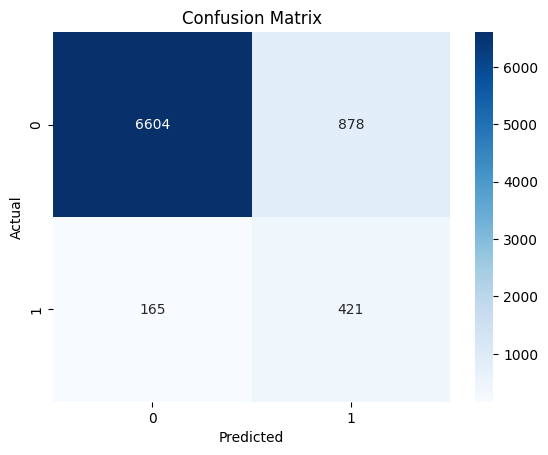

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


**AUC - ROC Curve :**

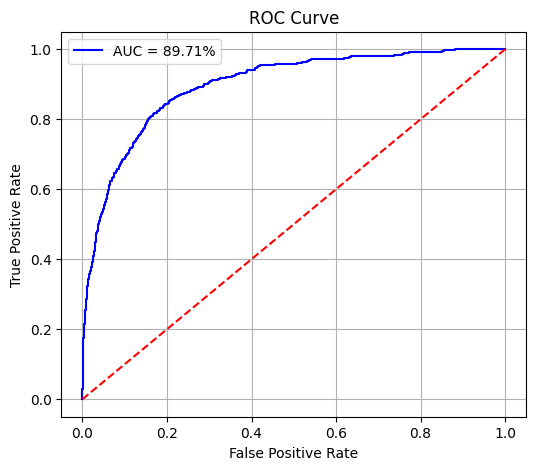

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Step 1: Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Step 2: Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Step 3: Compute AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Step 4: Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc*100:.2f}%")
plt.plot([0, 1], [0, 1], linestyle='--', color='red')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

### **Applying LSTM model :**

In [ ]:
full_df = full_df.sort_values(by=["patient_id", "ICULOS"]).reset_index(drop=True)
print(full_df.head(2))

     HR  O2Sat   Temp   SBP    MAP   DBP  Resp  BaseExcess  FiO2    pH  ...  \
0  97.0   95.0  36.11  98.0  75.33  62.0  19.0        24.0  0.28  7.36  ...   
1  97.0   95.0  36.11  98.0  75.33  62.0  19.0        24.0  0.28  7.36  ...   

   WBC  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  \
0  5.7      317.0  83.14       0    0.0    1.0        -0.03       1   
1  5.7      317.0  83.14       0    0.0    1.0        -0.03       2   

   SepsisLabel   patient_id  
0            0  p000001.psv  
1            0  p000001.psv  

[2 rows x 29 columns]


**Reconstruct continuous hourly rows :**

In [ ]:
full_df = full_df.sort_values(["patient_id", "ICULOS"]).reset_index(drop=True)

reconstructed = []

for pid, group in full_df.groupby("patient_id"):
    group = group.sort_values("ICULOS").copy()

    start = int(group["ICULOS"].min())
    end = int(group["ICULOS"].max())

    full_range = pd.RangeIndex(start=start, stop=end + 1)

    group = group.set_index("ICULOS").reindex(full_range)
    group.index.name = "ICULOS"

    group["patient_id"] = pid
    group["ICULOS"] = group.index

    group = group.ffill().bfill()

    reconstructed.append(group.reset_index(drop=True))

full_df_lstm = pd.concat(reconstructed, ignore_index=True)

print("Original shape:", full_df.shape)
print("Reconstructed shape:", full_df_lstm.shape)

Original shape: (1552210, 29)
Reconstructed shape: (1552210, 29)


**Choose LSTM input features :**

In [ ]:
feature_cols = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
    'BaseExcess', 'FiO2', 'pH', 'PaCO2', 'BUN', 'Calcium',
    'Creatinine', 'Glucose', 'Magnesium', 'Potassium',
    'Hct', 'Hgb', 'WBC', 'Platelets', 'Age', 'Gender', 'ICULOS'
]

**Scale features :**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
full_df_lstm[feature_cols] = scaler.fit_transform(full_df_lstm[feature_cols])

**Create patient sequences :**

In [ ]:
import numpy as np

X_sequences = []
y_labels = []

for patient_id, group in full_df_lstm.groupby("patient_id"):
    group = group.sort_values("ICULOS")
    X_sequences.append(group[feature_cols].values)
    y_labels.append(group["SepsisLabel"].max())

y_labels = np.array(y_labels)

print("Number of sequences:", len(X_sequences))
print("Number of labels:", len(y_labels))
print("Shape of first sequence:", X_sequences[33].shape)

Number of sequences: 40336
Number of labels: 40336
Shape of first sequence: (13, 24)


**Pad sequences :**

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_padded = pad_sequences(
    X_sequences,
    padding='post',
    dtype='float32'
)

print("Padded X shape:", X_padded.shape)
print("y shape:", y_labels.shape)

Padded X shape: (40336, 336, 24)
y shape: (40336,)


 **MODEL TRAINING :**

**Train-test split :**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

print(X_train.shape, X_test.shape)

(32268, 336, 24) (8068, 336, 24)


**Compute class weights :**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = {0: weights[0], 1: weights[1]}
print(class_weight_dict)

{0: np.float64(0.5392019250050131), 1: np.float64(6.877237851662404)}


**Build and train LSTM :**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking

model = Sequential([
    Masking(mask_value=0.0, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 336, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,897 (97.25 KB)

 Trainable params: 24,897 (97.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/5
807/807 ━━━━━━━━━━━━━━━━━━━━ 197s 236ms/step - accuracy: 0.7766 - loss: 0.5682 - val_accuracy: 0.8819 - val_loss: 0.4447
Epoch 2/5
807/807 ━━━━━━━━━━━━━━━━━━━━ 193s 225ms/step - accuracy: 0.8695 - loss: 0.4814 - val_accuracy: 0.8127 - val_loss: 0.5920
Epoch 3/5
807/807 ━━━━━━━━━━━━━━━━━━━━ 190s 236ms/step - accuracy: 0.8795 - loss: 0.4716 - val_accuracy: 0.8703 - val_loss: 0.4399
Epoch 4/5
807/807 ━━━━━━━━━━━━━━━━━━━━ 201s 235ms/step - accuracy: 0.8772 - loss: 0.4633 - val_accuracy: 0.8697 - val_loss: 0.4579
Epoch 5/5
807/807 ━━━━━━━━━━━━━━━━━━━━ 202s 235ms/step - accuracy: 0.8875 - loss: 0.4562 - val_accuracy: 0.8757 - val_loss: 0.4485


In [ ]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.4).astype(int)

253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob)*100:.2f}%")

[[6142 1340]
 [ 146  440]]
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      7482
           1       0.25      0.75      0.37       586

    accuracy                           0.82      8068
   macro avg       0.61      0.79      0.63      8068
weighted avg       0.92      0.82      0.85      8068

ROC-AUC: 85.76%


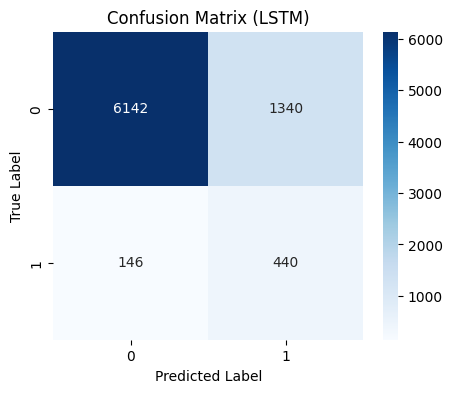

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 2: Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (LSTM)")

plt.show()

253/253 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step


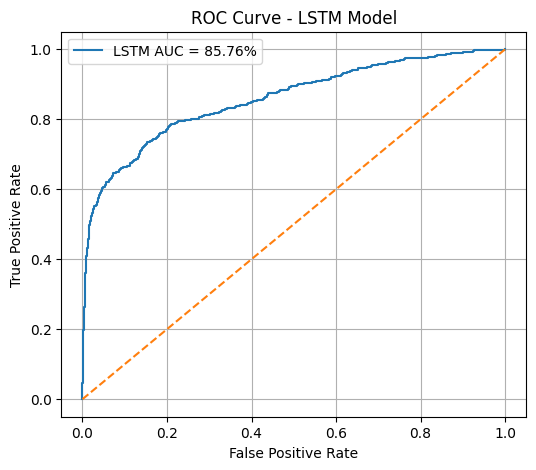

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Step 1: Get probabilities from LSTM
y_prob = model.predict(X_test).ravel()

# Step 2: Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Step 3: Compute AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Step 4: Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"LSTM AUC = {roc_auc*100:.2f}%")
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM Model")
plt.legend()
plt.grid()

plt.show()

**Results Comparision:**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Model": ["XGBoost", "LSTM"],
    "Accuracy": [0.87, 0.82],
    "Precision_Sepsis": [0.32, 0.25],
    "Recall_Sepsis": [0.72, 0.75],
    "F1_Sepsis": [0.45, 0.37],
    "ROC_AUC": [0.8971, 0.8576]
})


results_display = results_df.copy()
for col in ["Accuracy", "Precision_Sepsis", "Recall_Sepsis", "F1_Sepsis", "ROC_AUC"]:
    results_display[col] = results_display[col].apply(lambda x: f"{x*100:.2f}%")

print("Model Comparison Table:")
print(results_display)

Model Comparison Table:
     Model Accuracy Precision_Sepsis Recall_Sepsis F1_Sepsis ROC_AUC
0  XGBoost   87.00%           32.00%        72.00%    45.00%  89.71%
1     LSTM   82.00%           25.00%        75.00%    37.00%  85.76%


# **Model Comparison Summary**

Two approaches were implemented for early sepsis prediction:

- **XGBoost (Tabular Model):**
  Achieved strong overall performance with **ROC-AUC ~89.7%**, effectively capturing non-linear relationships in engineered features.

- **LSTM (Time-Series Model):**
  Leveraged temporal patient data and improved **recall (~75%)**, enabling better detection of sepsis cases.

###  Key Insight
While XGBoost provided higher overall discrimination, LSTM captured temporal progression patterns and improved sensitivity — a critical factor in healthcare applications where missing a sepsis case is costly.

 Both models complement each other:  
**XGBoost → strong baseline | LSTM → temporal learning**